In [4]:
#Load and clean data

import pandas as pd
import numpy as np

#Load expression data
rna = pd.read_csv(
    "../data/processed/shared/rna_shared_zscore.csv",
    index_col=0
)

microarray = pd.read_csv(
    "../data/processed/shared/microarray_shared_zscore.csv",
    index_col=0
)

print(rna.shape)
print(microarray.shape)

#Load metadata
rna_meta = pd.read_csv(
    "../data/processed/GSE234354/metadata_aligned.csv"
)

microarray_meta = pd.read_csv(
    "../data/processed/GSE234368/metadata_aligned.csv"
)

#Align metadata with matrices
rna_meta = rna_meta.set_index("sample_name")
microarray_meta = microarray_meta.set_index("sample_name")

#Reorder metadata to match X
rna_meta = rna_meta.loc[rna.index]
microarray_meta = microarray_meta.loc[microarray.index]


assert all(rna.index == rna_meta.index)
assert all(microarray.index == microarray_meta.index)


#Build out X
X_rna = rna
X_microarray = microarray

#Set stage map
stage_map = {
    "menstrual": 1,
    "early proliferative": 2,
    "mid proliferative": 3,
    "late proliferative": 4,
    "early secretory": 5,
    "mid secretory": 6,
    "late secretory": 7
}

y_rna = pd.to_numeric(rna_meta["cycle_stage"], errors="coerce")
y_microarray = pd.to_numeric(microarray_meta["cycle_stage"], errors="coerce")

#Handle missing values
mask = y_rna.notna()

X_rna = X_rna[mask]
y_rna = y_rna[mask]

mask = y_microarray.notna()

X_microarray = X_microarray[mask]
y_microarray = y_microarray[mask]

print(X_rna.shape, y_rna.shape)
print(X_microarray.shape, y_microarray.shape)

assert all(X_rna.columns == X_microarray.columns)

#Generate patient IDs
def get_patient_id(sample_name):
    return sample_name.split("_")[0]

groups = X_rna.index.to_series().apply(get_patient_id)

print(groups[groups.index.str.contains("_2")].head())

#No double patients so regular train/test split is safe

(295, 19194)
(290, 19194)
(257, 19194) (257,)
(268, 19194) (268,)
Series([], Name: sample_name, dtype: str)


In [5]:
#Train Elastic Net (Low L1 and High Alpha)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_predict
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns



X_train, X_test, y_train, y_test = train_test_split(
    X_rna, y_rna, test_size=0.2, random_state=42
)

EN_model_baseline = ElasticNetCV(
    l1_ratio=[0.1, 0.5, 0.9],
    alphas=[0.01, 0.1, 1],
    cv=5,
    n_jobs=-1,
    max_iter=5000
)

EN_model_baseline.fit(X_rna, y_rna)

print("Best alpha:", EN_model_baseline.alpha_)
print("Best l1_ratio:", EN_model_baseline.l1_ratio_)



preds = cross_val_predict(EN_model_baseline, X_rna, y_rna, cv=5)

print("MAE:", mean_absolute_error(y_rna, preds))

preds_micro = EN_model_baseline.predict(X_microarray)
print("MAE (microarray):", mean_absolute_error(y_microarray, preds_micro))
print("Spearman (microarray):", spearmanr(y_microarray, preds_micro))

print("Spearman (rna)", spearmanr(y_rna, EN_model_baseline.predict(X_rna)))


Best alpha: 1.0
Best l1_ratio: 0.1
MAE: 0.6989114993229273
MAE (microarray): 0.9064513081919344
Spearman (microarray): SignificanceResult(statistic=np.float64(0.8338630651647084), pvalue=np.float64(1.3094565073144322e-70))
Spearman (rna) SignificanceResult(statistic=np.float64(0.9187978904647964), pvalue=np.float64(6.176923814337322e-105))


/var/folders/kz/mkr0spbx1ldg9gvd0h39gq0r0000gn/T/ipykernel_3017/1175132862.py:8: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(lims, lims, 'r--', c="crimson")


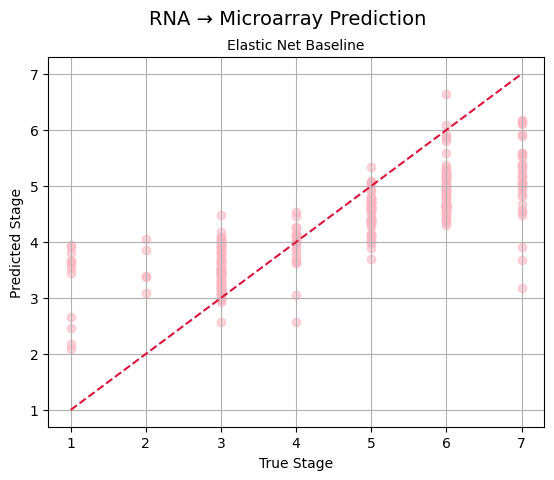

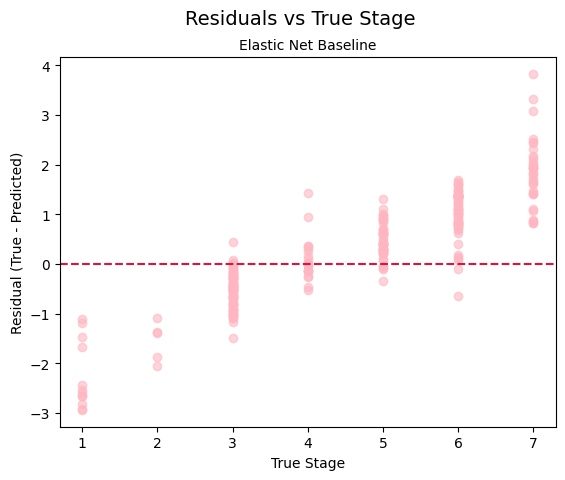

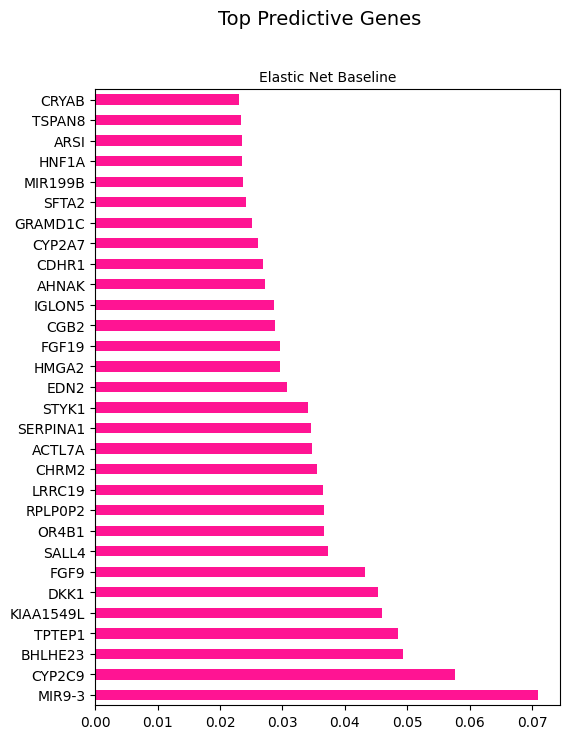

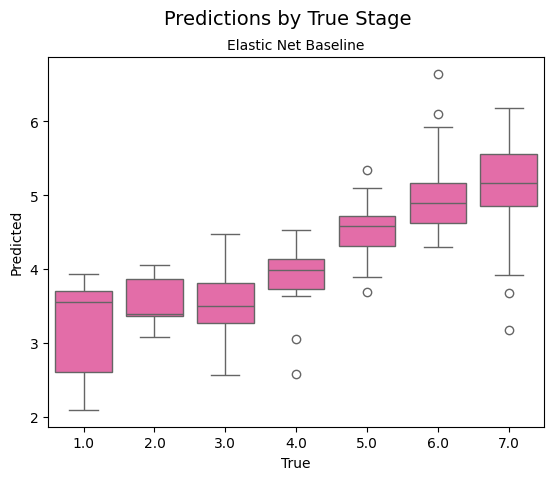

RNA Root Mean Squared Error Elastic Net: 1.069745857397337
Microarray Root Mean Squared Error Elastic Net: 1.141776444539301


In [6]:
#Visualizations for Elastic Net (Baseline)
from sklearn.metrics import mean_squared_error

plt.scatter(y_microarray, preds_micro, c="lightpink", alpha=0.6)

# Perfect prediction line
lims = [min(y_microarray), max(y_microarray)]
plt.plot(lims, lims, 'r--', c="crimson")

plt.xlabel("True Stage")
plt.ylabel("Predicted Stage")
plt.suptitle("RNA → Microarray Prediction", fontsize=14)
plt.title("Elastic Net Baseline", fontsize=10)

plt.grid(True)
plt.show()

#Residual plot
residuals = y_microarray - preds_micro

plt.scatter(y_microarray, residuals, alpha=0.6, c="lightpink")
plt.axhline(0, color='crimson', linestyle='--')

plt.xlabel("True Stage")
plt.ylabel("Residual (True - Predicted)")
plt.suptitle("Residuals vs True Stage", fontsize=14)
plt.title("Elastic Net Baseline", fontsize=10)

plt.show()


#Feature importance
coef = pd.Series(EN_model_baseline.coef_, index=X_rna.columns)

top_genes = coef.abs().sort_values(ascending=False).head(30)

top_genes.plot(kind="barh", figsize=(6,8), color="deeppink")
plt.suptitle("Top Predictive Genes", fontsize=14)
plt.title("Elastic Net Baseline", fontsize=10)
plt.show()

#Boxplot by Stage
df_plot = pd.DataFrame({
    "True": y_microarray,
    "Predicted": preds_micro
})

sns.boxplot(x="True", y="Predicted", data=df_plot, color="#f759a8")
plt.suptitle("Predictions by True Stage", fontsize=14)
plt.title("Elastic Net Baseline", fontsize=10)
plt.show()



rna_en_mse = mean_squared_error(y_rna, preds)
rna_en_rmse = np.sqrt(rna_en_mse)
print("RNA Root Mean Squared Error Elastic Net:", rna_en_rmse)

micro_en_mse = mean_squared_error(y_microarray, preds_micro)
micro_en_rmse = np.sqrt(micro_en_mse)
print("Microarray Root Mean Squared Error Elastic Net:", micro_en_rmse)

In [7]:
#Train PLS
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict

pls = PLSRegression(n_components=10)

preds_pls = cross_val_predict(pls, X_rna, y_rna, cv=5)

print(10, mean_absolute_error(y_rna, preds_pls))

pls.fit(X_rna, y_rna)
preds_pls_micro = pls.predict(X_microarray).ravel()


print("PLS MAE (microarray):", mean_absolute_error(y_microarray, preds_pls_micro))
print("PLS Spearman:", spearmanr(y_microarray, preds_pls_micro))


10 0.6929650845979283
PLS MAE (microarray): 0.7536550005707053
PLS Spearman: SignificanceResult(statistic=np.float64(0.8606690099617978), pvalue=np.float64(5.9983291859236895e-80))


/var/folders/kz/mkr0spbx1ldg9gvd0h39gq0r0000gn/T/ipykernel_3017/3911338118.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot([1,7],[1,7],'r--', c="crimson")


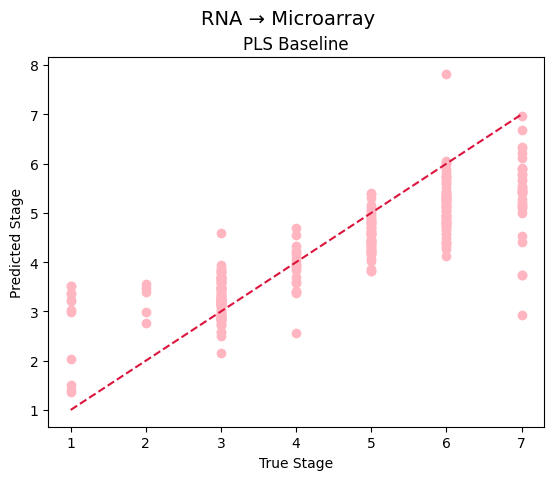

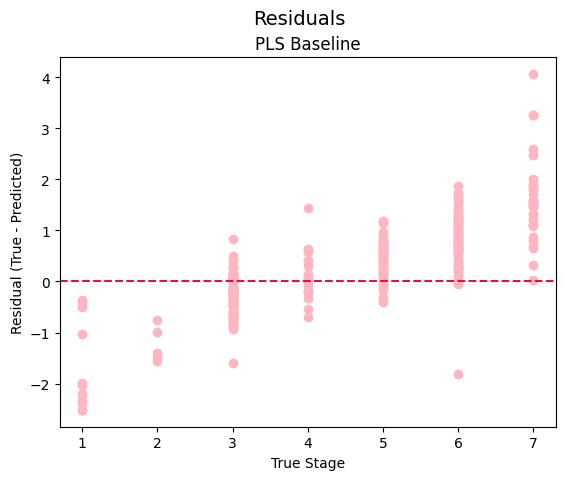

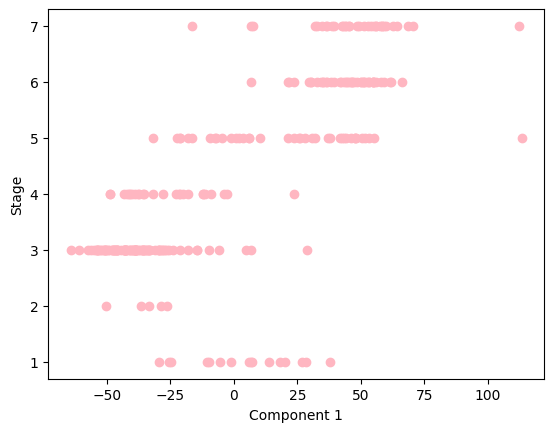

RNA Root Mean Squared Error PLS 1.069745857397337
Microarray Root Mean Squared Error PLS: 0.996383600128419


In [8]:
#PLS Visualization/Analysis

#Scatter prediction
plt.scatter(y_microarray, preds_pls_micro, c="lightpink")
plt.plot([1,7],[1,7],'r--', c="crimson")
plt.suptitle("RNA → Microarray", fontsize=14)
plt.title("PLS Baseline")
plt.xlabel("True Stage")
plt.ylabel("Predicted Stage")
plt.show()

#Residual plot
residuals_pls = y_microarray - preds_pls_micro

plt.scatter(y_microarray, residuals_pls, c="lightpink")
plt.axhline(0, linestyle='--', c="crimson")
plt.suptitle("Residuals", fontsize=14)
plt.title("PLS Baseline")
plt.xlabel("True Stage")
plt.ylabel("Residual (True - Predicted)")
plt.show()

#Component Analysis
components = pls.x_weights_

# top genes in first component
comp1 = pd.Series(components[:,0], index=X_rna.columns)
comp1.abs().sort_values(ascending=False).head(20)

#Plot Components by Stage
comp1_scores = pls.transform(X_rna)[:, 0]

plt.scatter(comp1_scores, y_rna, c="lightpink")
plt.xlabel("Component 1")
plt.ylabel("Stage")
plt.show()

rna_pls_mse = mean_squared_error(y_rna, preds_pls)
rna_pls_rmse = np.sqrt(rna_en_mse)
print("RNA Root Mean Squared Error PLS", rna_pls_rmse)
micro_pls_mse = mean_squared_error(y_microarray, preds_pls_micro)
micro_pls_rmse = np.sqrt(micro_pls_mse)
print("Microarray Root Mean Squared Error PLS:", micro_pls_rmse)



In [9]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import ElasticNet
from sklearn.multioutput import MultiOutputRegressor


N_STAGES = 7
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Circular encoding of targets
y_rna_arr = np.asarray(y_rna, dtype=float)
y_micro_arr = np.asarray(y_microarray, dtype=float)

theta_rna = 2 * np.pi * (y_rna_arr - 1) / N_STAGES
theta_micro = 2 * np.pi * (y_micro_arr - 1) / N_STAGES

Y_rna_circ = np.column_stack([np.cos(theta_rna), np.sin(theta_rna)])
Y_micro_circ = np.column_stack([np.cos(theta_micro), np.sin(theta_micro)])

# PLS model
pls = PLSRegression(n_components=10)

# CV predictions (RNA)
Y_rna_pls_cv = cross_val_predict(pls, X_rna, Y_rna_circ, cv=cv)

theta_pred_rna_pls = np.mod(np.arctan2(Y_rna_pls_cv[:, 1], Y_rna_pls_cv[:, 0]), 2 * np.pi)
y_rna_pls_cv = theta_pred_rna_pls * N_STAGES / (2 * np.pi) + 1

# Fit full model and predict microarray
pls.fit(X_rna, Y_rna_circ)
Y_micro_pls = pls.predict(X_microarray)

theta_pred_micro_pls = np.mod(np.arctan2(Y_micro_pls[:, 1], Y_micro_pls[:, 0]), 2 * np.pi)
y_micro_pls = theta_pred_micro_pls * N_STAGES / (2 * np.pi) + 1

# Elastic Net model (multi-output)
enet = MultiOutputRegressor(
    ElasticNet(alpha=0.1, l1_ratio=0.1, max_iter=10000, random_state=42)
)

# CV predictions (RNA)
Y_rna_enet_cv = cross_val_predict(enet, X_rna, Y_rna_circ, cv=cv)

theta_pred_rna_enet = np.mod(np.arctan2(Y_rna_enet_cv[:, 1], Y_rna_enet_cv[:, 0]), 2 * np.pi)
y_rna_enet_cv = theta_pred_rna_enet * N_STAGES / (2 * np.pi) + 1

# Fit full model and predict microarray
enet.fit(X_rna, Y_rna_circ)
Y_micro_enet = enet.predict(X_microarray)

theta_pred_micro_enet = np.mod(np.arctan2(Y_micro_enet[:, 1], Y_micro_enet[:, 0]), 2 * np.pi)
y_micro_enet = theta_pred_micro_enet * N_STAGES / (2 * np.pi) + 1

# Evaluation helper 
def evaluate(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    diff = np.abs(y_true - y_pred)
    circ_diff = np.minimum(diff, N_STAGES - diff)

    s = spearmanr(y_true, y_pred)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "Circular_MAE": np.mean(circ_diff),
        "Circular_MSE": np.mean(circ_diff**2),
        "Circular_RMSE": np.sqrt(np.mean(circ_diff**2)),
        "Spearman": s.statistic,
        "p-value": s.pvalue,
    }


#Collect results
results = []

results.append({"Model": "PLS CV (RNA)", **evaluate(y_rna_arr, y_rna_pls_cv)})
results.append({"Model": "PLS RNA→Microarray", **evaluate(y_micro_arr, y_micro_pls)})
results.append({"Model": "ElasticNet CV (RNA)", **evaluate(y_rna_arr, y_rna_enet_cv)})
results.append({"Model": "ElasticNet RNA→Microarray", **evaluate(y_micro_arr, y_micro_enet)})

results_df = pd.DataFrame(results)
print(results_df)

# Inspect predictions
rna_pred_df = pd.DataFrame({
    "true": y_rna_arr,
    "pls_cv": y_rna_pls_cv,
    "enet_cv": y_rna_enet_cv
}, index=X_rna.index)

print("\nRNA predictions:")
print(rna_pred_df.head())

micro_pred_df = pd.DataFrame({
    "true": y_micro_arr,
    "pls": y_micro_pls,
    "enet": y_micro_enet
}, index=X_microarray.index)

print("\nMicroarray predictions:")
print(micro_pred_df.head())




                       Model       MAE       MSE      RMSE  Circular_MAE  \
0               PLS CV (RNA)  0.652980  1.892207  1.375575      0.431747   
1         PLS RNA→Microarray  0.558276  1.143707  1.069443      0.451227   
2        ElasticNet CV (RNA)  0.706556  2.078298  1.441630      0.468223   
3  ElasticNet RNA→Microarray  0.686286  1.122748  1.059598      0.626983   

   Circular_MSE  Circular_RMSE  Spearman       p-value  
0      0.343572       0.586151  0.689247  1.485554e-37  
1      0.394367       0.627986  0.808632  3.138074e-63  
2      0.409964       0.640284  0.653142  1.216002e-32  
3      0.707631       0.841208  0.817048  1.453701e-65  

RNA predictions:
             true    pls_cv   enet_cv
sample_name                          
X210000       7.0  2.087914  2.431659
X210013       3.0  3.002350  3.247720
X210018       7.0  7.085904  7.378629
X210046       3.0  3.068640  2.865502
X210047       7.0  6.770690  6.904168

Microarray predictions:
             true       p

Text(0, 0.5, 'Predicted Stage')

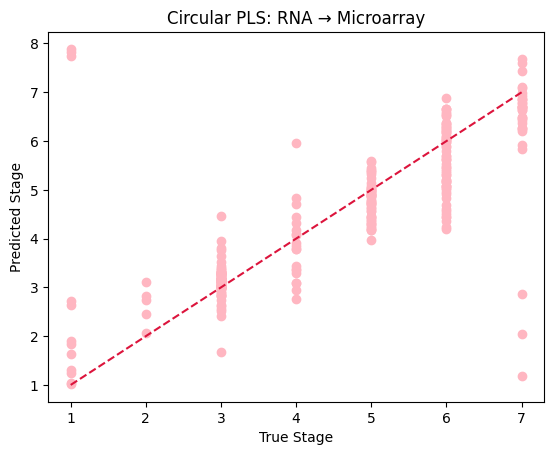

In [10]:
#Plot Circular Models
plt.scatter(y_microarray, y_micro_pls, c="lightpink")
plt.plot([1,7],[1,7],'--', c="crimson")
plt.title("Circular PLS: RNA → Microarray")
plt.xlabel("True Stage")
plt.ylabel("Predicted Stage")



In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import rankdata

# Continuous Time Circular PLS Model

N_STAGES = 7
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Make sure targets are numeric
y_rna_arr = np.asarray(y_rna, dtype=float)
y_micro_arr = np.asarray(y_microarray, dtype=float)

# Build a continuous RNA ordering signal

pls_base = PLSRegression(n_components=15)
pls_base.fit(X_rna, y_rna_arr)

rna_score = pls_base.transform(X_rna)[:, 0]
micro_score = pls_base.transform(X_microarray)[:, 0]

# RNA continuous proportion on [0, 1]
rna_prop = (rankdata(rna_score, method="average") - 1) / (len(rna_score) - 1)

# Map microarray scores onto the same RNA-derived scale
rna_sorted = np.sort(rna_score)
micro_prop = np.searchsorted(rna_sorted, micro_score, side="right") / len(rna_sorted)
micro_prop = np.clip(micro_prop, 0.0, 1.0)

# Convert continuous proportions to circular targets
theta_rna = 2 * np.pi * rna_prop
theta_micro = 2 * np.pi * micro_prop

Y_rna_circ = np.column_stack([np.cos(theta_rna), np.sin(theta_rna)])

# Circular PLS with RNA CV
pls_circ_cv = PLSRegression(n_components=15)
Y_rna_cv = cross_val_predict(pls_circ_cv, X_rna, Y_rna_circ, cv=cv)

theta_rna_cv = np.mod(np.arctan2(Y_rna_cv[:, 1], Y_rna_cv[:, 0]), 2 * np.pi)
rna_prop_cv = theta_rna_cv / (2 * np.pi)
rna_prop_cv = np.clip(rna_prop_cv, 0.0, 1.0)

rna_stage_cv = rna_prop_cv * (N_STAGES - 1) + 1
rna_stage_cv = np.clip(rna_stage_cv, 1.0, float(N_STAGES))

# Fit final circular PLS on all RNA
pls_circ = PLSRegression(n_components=15)
pls_circ.fit(X_rna, Y_rna_circ)

# External test on microarray
Y_micro_pred = pls_circ.predict(X_microarray)

theta_micro_pred = np.mod(np.arctan2(Y_micro_pred[:, 1], Y_micro_pred[:, 0]), 2 * np.pi)
micro_prop_pred = theta_micro_pred / (2 * np.pi)
micro_prop_pred = np.clip(micro_prop_pred, 0.0, 1.0)

micro_stage_pred = micro_prop_pred * (N_STAGES - 1) + 1
micro_stage_pred = np.clip(micro_stage_pred, 1.0, float(N_STAGES))

# Continuous-scale evaluation
rna_cont_diff = np.abs(rna_prop - rna_prop_cv)
rna_cont_circ_diff = np.minimum(rna_cont_diff, 1.0 - rna_cont_diff)
rna_cont_spear = spearmanr(rna_prop, rna_prop_cv)

micro_cont_diff = np.abs(micro_prop - micro_prop_pred)
micro_cont_circ_diff = np.minimum(micro_cont_diff, 1.0 - micro_cont_diff)
micro_cont_spear = spearmanr(micro_prop, micro_prop_pred)

# Stage-scale evaluation
rna_stage_diff = np.abs(y_rna_arr - rna_stage_cv)
rna_stage_circ_diff = np.minimum(rna_stage_diff, N_STAGES - rna_stage_diff)
rna_stage_spear = spearmanr(y_rna_arr, rna_stage_cv)

micro_stage_diff = np.abs(y_micro_arr - micro_stage_pred)
micro_stage_circ_diff = np.minimum(micro_stage_diff, N_STAGES - micro_stage_diff)
micro_stage_spear = spearmanr(y_micro_arr, micro_stage_pred)

# Results table
results = pd.DataFrame([
    {
        "Model": "Circular PLS CV (RNA)",
        "Scale": "Continuous",
        "MAE": mean_absolute_error(rna_prop, rna_prop_cv),
        "MSE": mean_squared_error(rna_prop, rna_prop_cv),
        "RMSE": np.sqrt(mean_squared_error(rna_prop, rna_prop_cv)),
        "Circular_MAE": np.mean(rna_cont_circ_diff),
        "Circular_MSE": np.mean(rna_cont_circ_diff ** 2),
        "Circular_RMSE": np.sqrt(np.mean(rna_cont_circ_diff ** 2)),
        "Spearman": rna_cont_spear.statistic,
        "p-value": rna_cont_spear.pvalue,
    },
    {
        "Model": "Circular PLS RNA -> Microarray",
        "Scale": "Continuous",
        "MAE": mean_absolute_error(micro_prop, micro_prop_pred),
        "MSE": mean_squared_error(micro_prop, micro_prop_pred),
        "RMSE": np.sqrt(mean_squared_error(micro_prop, micro_prop_pred)),
        "Circular_MAE": np.mean(micro_cont_circ_diff),
        "Circular_MSE": np.mean(micro_cont_circ_diff ** 2),
        "Circular_RMSE": np.sqrt(np.mean(micro_cont_circ_diff ** 2)),
        "Spearman": micro_cont_spear.statistic,
        "p-value": micro_cont_spear.pvalue,
    },
    {
        "Model": "Circular PLS CV (RNA)",
        "Scale": "Stage",
        "MAE": mean_absolute_error(y_rna_arr, rna_stage_cv),
        "MSE": mean_squared_error(y_rna_arr, rna_stage_cv),
        "RMSE": np.sqrt(mean_squared_error(y_rna_arr, rna_stage_cv)),
        "Circular_MAE": np.mean(rna_stage_circ_diff),
        "Circular_MSE": np.mean(rna_stage_circ_diff ** 2),
        "Circular_RMSE": np.sqrt(np.mean(rna_stage_circ_diff ** 2)),
        "Spearman": rna_stage_spear.statistic,
        "p-value": rna_stage_spear.pvalue,
    },
    {
        "Model": "Circular PLS RNA -> Microarray",
        "Scale": "Stage",
        "MAE": mean_absolute_error(y_micro_arr, micro_stage_pred),
        "MSE": mean_squared_error(y_micro_arr, micro_stage_pred),
        "RMSE": np.sqrt(mean_squared_error(y_micro_arr, micro_stage_pred)),
        "Circular_MAE": np.mean(micro_stage_circ_diff),
        "Circular_MSE": np.mean(micro_stage_circ_diff ** 2),
        "Circular_RMSE": np.sqrt(np.mean(micro_stage_circ_diff ** 2)),
        "Spearman": micro_stage_spear.statistic,
        "p-value": micro_stage_spear.pvalue,
    },
])

print(results)




                            Model       Scale       MAE       MSE      RMSE  \
0           Circular PLS CV (RNA)  Continuous  0.064865  0.009999  0.099996   
1  Circular PLS RNA -> Microarray  Continuous  0.158007  0.033765  0.183752   
2           Circular PLS CV (RNA)       Stage  0.978485  1.769960  1.330398   
3  Circular PLS RNA -> Microarray       Stage  0.812563  1.288135  1.134961   

   Circular_MAE  Circular_MSE  Circular_RMSE  Spearman        p-value  
0      0.061203      0.006337       0.079607  0.936452  5.189407e-118  
1      0.157199      0.032956       0.181538  0.912225  4.383922e-105  
2      0.930727      1.435654       1.198188  0.720346   2.110200e-42  
3      0.796669      1.176873       1.084838  0.780272   3.812927e-56  


[0.46633016 0.71176709 0.78539816 0.319068   0.26998062 0.3436117
 0.39269908 0.19634954 0.04908739 0.29452431 0.44178647 0.17180585
 0.22089323 0.07363108 0.12271846 0.02454369 0.24543693 0.61359232
 0.09817477 0.56450493 0.58904862 0.76085447 0.41724277 0.14726216
 0.49087385 0.53996124 0.51541754 0.6626797  0.         0.63813601
 0.68722339 0.36815539 0.73631078]


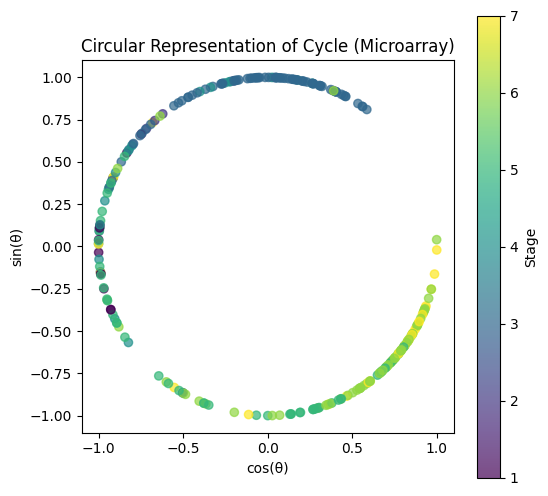

Text(0, 0.5, 'Predicted Stage')

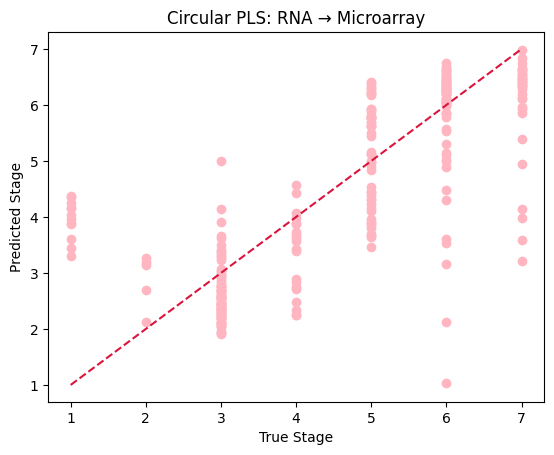

In [12]:
#Continuous Circular Model Visualizations
print(theta_rna[(theta_rna>=0) & (theta_rna<=(np.pi/4))])
# Use your predicted theta
x = np.cos(theta_micro_pred)
y = np.sin(theta_micro_pred)

plt.figure(figsize=(6,6))
plt.scatter(x, y, c=y_microarray, cmap='viridis', alpha=0.7)

plt.xlabel("cos(θ)")
plt.ylabel("sin(θ)")
plt.title("Circular Representation of Cycle (Microarray)")
plt.gca().set_aspect('equal')

plt.colorbar(label="Stage")
plt.show()


plt.scatter(y_microarray, micro_stage_pred, c="lightpink")
plt.plot([1,7],[1,7],'--', c="crimson")
plt.title("Circular PLS: RNA → Microarray")
plt.xlabel("True Stage")
plt.ylabel("Predicted Stage")

                     Gene_set  \
0  GO_Biological_Process_2021   
1  GO_Biological_Process_2021   
2  GO_Biological_Process_2021   
3  GO_Biological_Process_2021   
4  GO_Biological_Process_2021   

                                                Term Overlap   P-value  \
0  negative regulation of synapse organization (G...     1/5  0.004492   
1        white fat cell differentiation (GO:0050872)     1/7  0.006284   
2  positive regulation of synaptic plasticity (GO...     1/7  0.006284   
3  negative regulation of inflammatory response t...   2/136  0.006539   
4  regulation of inflammatory response to antigen...   2/137  0.006633   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.074207            0                     0  293.794118   
1          0.074207            0                     0  195.843137   
2          0.074207            0                     0  195.843137   
3          0.074207            0                     0   18.514925   
4     

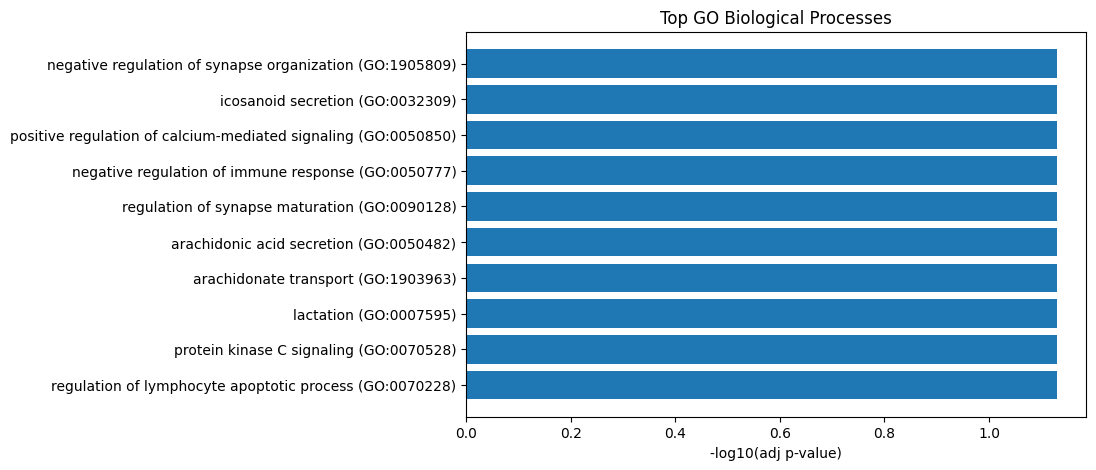

<Axes: xlabel='Combined Score', ylabel='Term'>

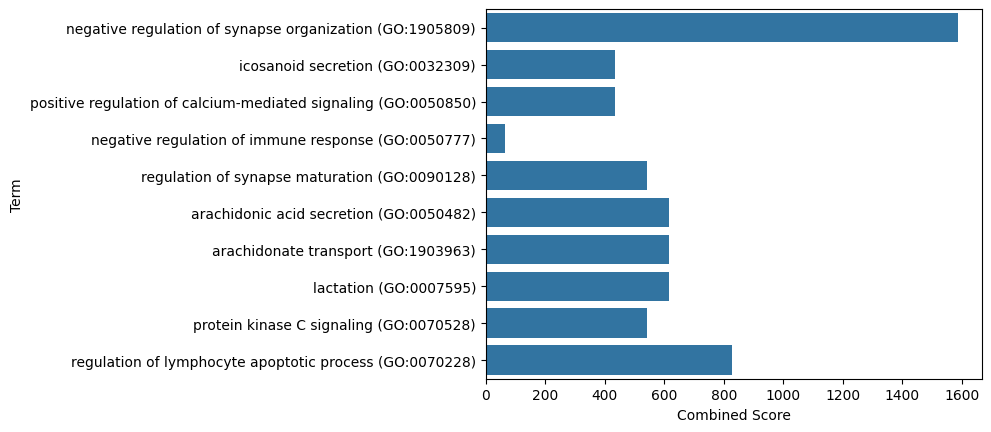

In [13]:
#Gene Ontology Analysis
import gseapy as gp
import matplotlib.pyplot as plt
#Enet
coef_cos = enet.estimators_[0].coef_
coef_sin = enet.estimators_[1].coef_

enet_importance = np.sqrt(coef_cos**2 + coef_sin**2)

enet_importance_series = pd.Series(enet_importance, index=X_rna.columns)
enet_top_genes = enet_importance_series.sort_values(ascending=False).head(100)

#PLS
pls_weights = pls.x_weights_

pls_importance = np.linalg.norm(pls_weights, axis=1)

pls_importance_series = pd.Series(pls_importance, index=X_rna.columns)

pls_top_genes = pls_importance_series.sort_values(ascending=False).head(100)

#Overlap
overlap_genes = set(pls_top_genes.index).intersection(set(enet_top_genes.index))
gene_list = list(overlap_genes)


enr = gp.enrichr(
    gene_list=gene_list,
    gene_sets=["GO_Biological_Process_2021"],
    organism="human",
    outdir=None
)

results = enr.results
print(results.head())


# Sort by adjusted p-value (smallest = most significant)
top_terms = results.sort_values("Adjusted P-value").head(10)

plt.figure(figsize=(8,5))
plt.barh(top_terms["Term"], -np.log10(top_terms["Adjusted P-value"]))

plt.xlabel("-log10(adj p-value)")
plt.title("Top GO Biological Processes")
plt.gca().invert_yaxis()

plt.show()

sns.barplot(
    x="Combined Score",
    y="Term",
    data=top_terms
)

   Ensembl.Gene.ID Associated.Gene.Name  \
0  ENSG00000000003               TSPAN6   
1  ENSG00000000005                 TNMD   
2  ENSG00000000419                 DPM1   
3  ENSG00000000457                SCYL3   
4  ENSG00000000460             C1orf112   

                                         Description  P1_13063_Run1-3_counts  \
0       tetraspanin 6 [Source:HGNC Symbol;Acc:11858]                     318   
1         tenomodulin [Source:HGNC Symbol;Acc:17757]                       0   
2  dolichyl-phosphate mannosyltransferase polypep...                     364   
3  SCY1-like 3 (S. cerevisiae) [Source:HGNC Symbo...                     306   
4  chromosome 1 open reading frame 112 [Source:HG...                      67   

   P2_13244_Run1-3_counts  P3_14033_Run1-3_counts  P4_14043_Run1-3_counts  \
0                     415                     323                     520   
1                       0                       1                       0   
2                     334    

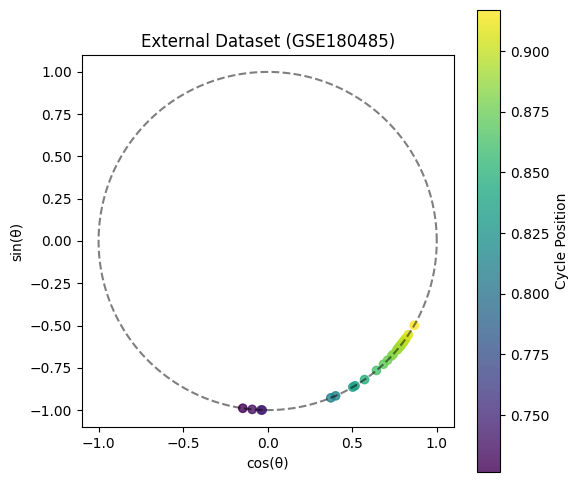

In [19]:
#Extrnal Validation with GSE180485
import pandas as pd
import numpy as np 
#XLSX File downloaded from https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE180485
df = pd.read_excel("../data/processed/GSE180485/GSE180485_EndoTime_RNA_counts_TPM.xlsx")

print(df.head())

#Set gene names
df = df.set_index("Associated.Gene.Name")

#Drop extra columns
df = df.drop(columns=["Ensembl.Gene.ID", "Description"])

#Collapse duplicate genes
df = df.groupby(df.index).mean()

#Transpose to match model
X_external = df.T

#Load RNA Scaling Data
rna_mu = pd.read_csv("../data/processed/shared/rna_shared_mean.csv", index_col=0).squeeze()
rna_sd = pd.read_csv("../data/processed/shared/rna_shared_std.csv", index_col=0).squeeze()

# Match genes first
shared_genes = X_rna.columns.intersection(X_external.columns)

X_rna_shared = X_rna[shared_genes]
X_external = X_external[shared_genes]

#Refit model with only shared gene set
pls_circ.fit(X_rna_shared, Y_rna_circ)

rna_mu = rna_mu[shared_genes]
rna_sd = rna_sd[shared_genes]

X_external_scaled = ((X_external - rna_mu) / rna_sd).fillna(0.0)

Y_external_pred = pls_circ.predict(X_external_scaled)

theta_external = np.mod(
    np.arctan2(Y_external_pred[:,1], Y_external_pred[:,0]),
    2*np.pi
)

external_prop = theta_external / (2*np.pi)

plt.figure(figsize=(6,6))
plt.scatter(
    np.cos(theta_external),
    np.sin(theta_external),
    c=external_prop,
    cmap="viridis",
    alpha=0.8
)

#Reference circle
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.5)

# Formatting
plt.gca().set_aspect('equal')
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)

plt.xlabel("cos(θ)")
plt.ylabel("sin(θ)")
plt.title("External Dataset (GSE180485)")

plt.colorbar(label="Cycle Position")

plt.show()